# P04 — UK House Price Dynamics
## Notebook 03: Visualisation

This notebook produces five production-grade figures at 300 DPI for P04.
All figures are saved to the figures/ directory and are ready for the
README and policy brief.

The five figures are:

1. Horizontal bar chart — top 20 and bottom 20 LAs by affordability ratio
2. Box plots — affordability ratio distribution by region, ordered by median
3. Grouped bar chart — median price by property type and region
4. Line chart — regional median price 2015 to 2022 showing post-COVID surge
5. Scatter plot — IMD score vs affordability ratio with regional colour coding

## Section 1 — Environment Setup

We verify the working directory, import all libraries, load config.py and
read the analysis-ready dataset from 02_analysis.

In [1]:
import os
import sys

os.getcwd()

'C:\\Users\\TEST\\OneDrive\\Documents\\The United Kingdom\\Jobs\\Data Science\\portfolio\\project4\\notebooks'

In [14]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
import config

# Load analysis-ready dataset
df = pd.read_csv(config.HOUSE_PRICES_FINAL)

# Load HPSSA for temporal price series (figure 4)
hpssa_raw = pd.read_csv(config.HPSSA_LA, dtype=str)

print(f"Main dataset: {df.shape}")
print(f"HPSSA raw: {hpssa_raw.shape}")
print(f"\nMatplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Main dataset: (296, 12)
HPSSA raw: (741600, 14)

Matplotlib version: 3.10.8
Seaborn version: 0.13.2


## Section 2 — Figure 1: Affordability Ratio Bar Chart

Figure 1 shows the top 20 least affordable and top 20 most affordable
English local authorities by affordability ratio in 2024. A horizontal
bar chart is used because LA names are long and read more clearly on the
y-axis than the x-axis. The two groups are displayed in a single figure
using two subplots side by side, with a shared x-axis scale to allow
direct visual comparison.

Bars are coloured by region so spatial clustering is immediately visible
without needing to read every label.

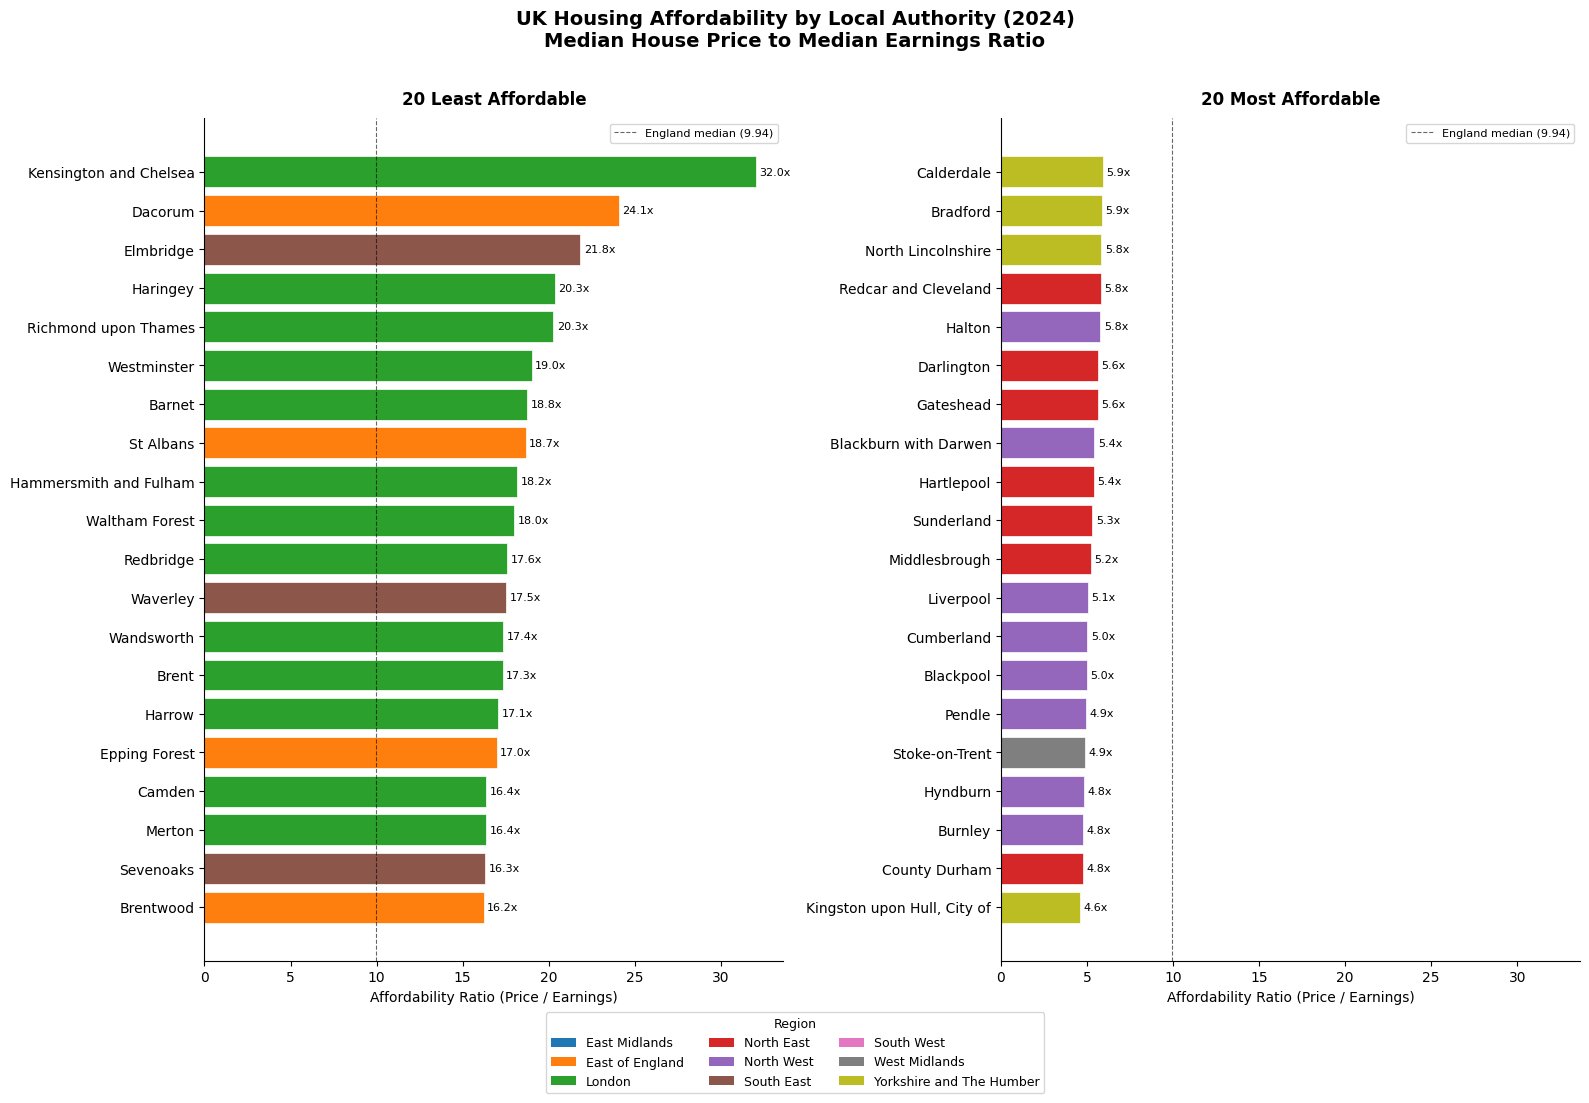

Saved: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project4\figures\01_affordability_ratio_bar.png


In [3]:
# Prepare data
df_fig1 = df.dropna(subset=["affordability_ratio"]).copy()
df_fig1 = df_fig1.sort_values("affordability_ratio", ascending=False)

top20    = df_fig1.head(20).copy()
bottom20 = df_fig1.tail(20).copy()

# Region colour palette — one colour per region
regions = sorted(df_fig1["region_name"].unique())
palette = dict(zip(regions, sns.color_palette("tab10", len(regions))))

# Shared x-axis limit
x_max = top20["affordability_ratio"].max() * 1.05

fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=False)
fig.suptitle(
    "UK Housing Affordability by Local Authority (2024)\n"
    "Median House Price to Median Earnings Ratio",
    fontsize=14, fontweight="bold", y=1.01
)

for ax, data, title in zip(
    axes,
    [top20, bottom20],
    ["20 Least Affordable", "20 Most Affordable"]
):
    data = data.sort_values("affordability_ratio", ascending=True)
    colours = [palette[r] for r in data["region_name"]]

    bars = ax.barh(
        data["lad_name"],
        data["affordability_ratio"],
        color=colours,
        edgecolor="white",
        linewidth=0.5
    )

    # Add value labels
    for bar, val in zip(bars, data["affordability_ratio"]):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}x",
            va="center", ha="left", fontsize=8
        )

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Affordability Ratio (Price / Earnings)", fontsize=10)
    ax.set_xlim(0, x_max)
    ax.axvline(x=9.94, color="black", linestyle="--",
               linewidth=0.8, alpha=0.6, label="England median (9.94)")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Region legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=palette[r], label=r) for r in regions
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    fontsize=9,
    title="Region",
    title_fontsize=9,
    bbox_to_anchor=(0.5, -0.08)
)

plt.tight_layout()
plt.savefig(config.FIG_AFFORDABILITY_BAR, dpi=config.FIGURE_DPI,
            bbox_inches="tight")
plt.show()
print(f"Saved: {config.FIG_AFFORDABILITY_BAR}")

### Explanation of Figure Above
The regional colour coding works well -- London green dominates the least affordable panel, North East red and North West purple dominate the most affordable panel. The England median dashed line gives an immediate reference point. Value labels are clean and readable. The shared legend at the bottom is well positioned.

## Section 3 — Figure 2: Regional Affordability Box Plots

Figure 2 shows the distribution of affordability ratios within each
English region using box plots. Regions are ordered by median
affordability ratio from least affordable (left) to most affordable
(right). Box plots reveal not just the regional median but also the
spread and skew within each region -- London in particular has a wide
spread driven by the contrast between prime central boroughs and outer
London LAs.

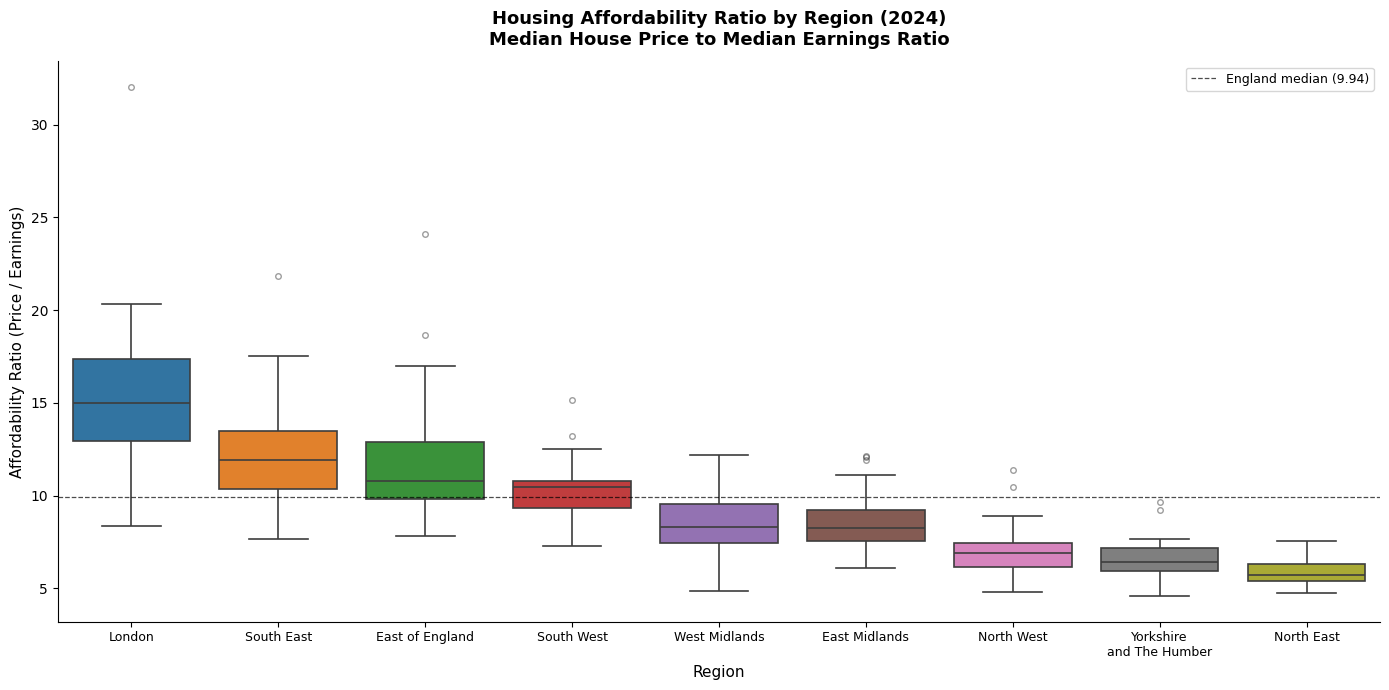

Saved: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project4\figures\02_regional_affordability.png


In [4]:
# Prepare data
df_fig2 = df.dropna(subset=["affordability_ratio"]).copy()

# Order regions by median affordability ratio descending
region_order = (
    df_fig2.groupby("region_name")["affordability_ratio"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=df_fig2,
    x="region_name",
    y="affordability_ratio",
    order=region_order,
    palette="tab10",
    linewidth=1.2,
    flierprops=dict(marker="o", markersize=4, alpha=0.5),
    ax=ax
)

# England median reference line
ax.axhline(y=9.94, color="black", linestyle="--",
           linewidth=0.9, alpha=0.7, label="England median (9.94)")

ax.set_title(
    "Housing Affordability Ratio by Region (2024)\n"
    "Median House Price to Median Earnings Ratio",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Region", fontsize=11)
ax.set_ylabel("Affordability Ratio (Price / Earnings)", fontsize=11)

# Wrap long region names
region_labels = [r.replace(" and ", "\nand ") for r in region_order]
ticks = range(len(region_order))
ax.set_xticks(ticks)
ax.set_xticklabels(region_labels, fontsize=9)

ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(config.FIG_REGIONAL_BOX, dpi=config.FIGURE_DPI,
            bbox_inches="tight")
plt.show()
print(f"Saved: {config.FIG_REGIONAL_BOX}")

### Explanation of Figure Above

The regional ordering tells the story immediately -- London far above the England median line, North East well below it, with a clean gradient from left to right. The London box is wide, showing high within-region variation. The Kensington and Chelsea outlier at 32 is clearly visible as an isolated point above the London whisker. The England median dashed line cuts through South West, which sits almost exactly at the national median.

## Section 4 — Figure 3: Median Price by Property Type and Region

Figure 3 shows median house price broken down by property type (Detached,
Semi-Detached, Terraced, Flat) and region. This reveals how the property
type premium varies geographically -- in London the flat premium relative
to the national flat median is extreme, while the detached premium is
largest in the South East and East of England.

We aggregate the transaction-level PPD data to compute median prices by
property type and region directly from the raw transactions, giving us
more granular breakdowns than the LA-level aggregates allow.

In [5]:
# Reload PPD aggregated by property type and region
# We need transaction-level property type data — reload from processed file
# and merge region from df

# Load house_prices_final for region lookup
region_lookup = df[["lad_code", "region_name"]].drop_duplicates()

# We need to re-aggregate from the ONSPD-merged PPD
# Since ppd_geo is not in memory, we use the HPSSA property type breakdown
# from the raw HPSSA file which has property type splits

hpssa_raw2 = pd.read_csv(config.HPSSA_LA, dtype=str)

# Filter to median price, all build status, most recent year (2022), England
hpssa_type = hpssa_raw2[
    (hpssa_raw2["house-sales-and-prices"] == "median") &
    (hpssa_raw2["build-status"] == "all") &
    (hpssa_raw2["calendar-years"] == "2022") &
    (hpssa_raw2["property-type"] != "all") &
    (hpssa_raw2["Data Marking"].isna())
].copy()

hpssa_type = hpssa_type[
    hpssa_type["administrative-geography"].str.startswith("E", na=False)
].copy()

hpssa_type = hpssa_type[[
    "administrative-geography", "Geography",
    "property-type", "PropertyType", "V4_1"
]].copy()

hpssa_type.columns = [
    "lad_code", "lad_name", "property_type_code",
    "property_type", "median_price"
]

hpssa_type["median_price"] = pd.to_numeric(
    hpssa_type["median_price"], errors="coerce"
)

# Merge region
hpssa_type = hpssa_type.merge(region_lookup, on="lad_code", how="left")
hpssa_type = hpssa_type.dropna(subset=["region_name", "median_price"])

# Regional median by property type
region_type = (
    hpssa_type.groupby(["region_name", "property_type"])["median_price"]
    .median()
    .reset_index()
)

print(f"Property type rows: {region_type.shape[0]}")
print(region_type.head(8))

Property type rows: 36
       region_name    property_type  median_price
0    East Midlands         Detached      295000.0
1    East Midlands  Flat/maisonette      117500.0
2    East Midlands    Semi-detached      189000.0
3    East Midlands         Terraced      161000.0
4  East of England         Detached      480000.0
5  East of England  Flat/maisonette      184000.0
6  East of England    Semi-detached      335000.0
7  East of England         Terraced      280000.0


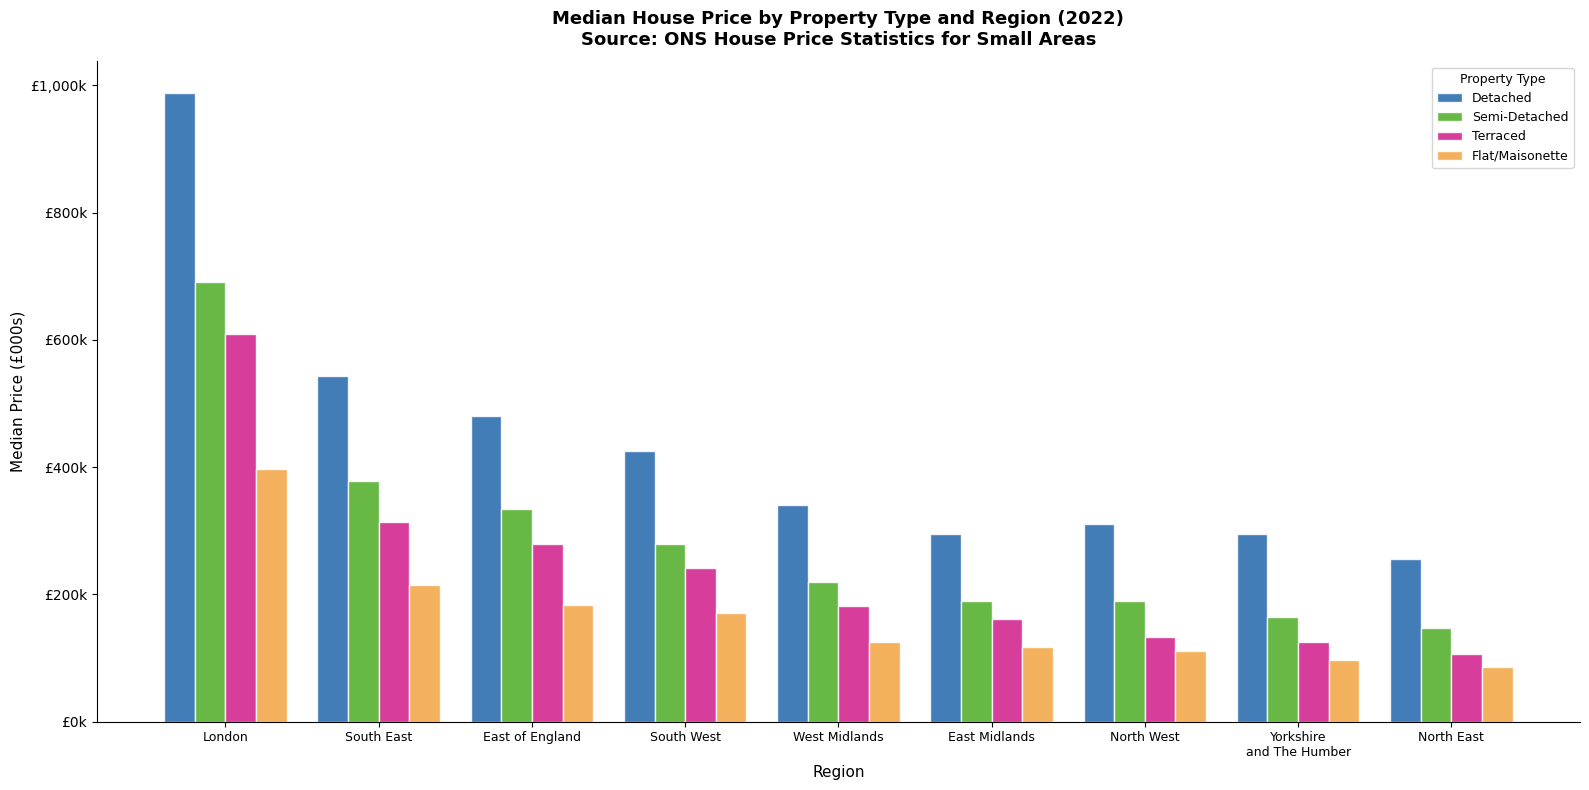

Saved: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project4\figures\03_property_type_prices.png


In [6]:
# Clean property type labels and set display order
type_order = ["Detached", "Semi-Detached", "Terraced", "Flat/Maisonette"]

region_type["property_type"] = region_type["property_type"].str.replace(
    "Semi-detached", "Semi-Detached"
).str.replace("Flat/maisonette", "Flat/Maisonette")

# Order regions by overall median price descending
region_order = (
    region_type.groupby("region_name")["median_price"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(16, 8))

# Grouped bar chart
x = np.arange(len(region_order))
width = 0.2
type_colours = ["#2166ac", "#4dac26", "#d01c8b", "#f1a340"]

for i, (ptype, colour) in enumerate(zip(type_order, type_colours)):
    vals = [
        region_type[
            (region_type["region_name"] == r) &
            (region_type["property_type"] == ptype)
        ]["median_price"].values[0] / 1000
        for r in region_order
    ]
    bars = ax.bar(
        x + i * width, vals, width,
        label=ptype, color=colour, alpha=0.85, edgecolor="white"
    )

ax.set_title(
    "Median House Price by Property Type and Region (2022)\n"
    "Source: ONS House Price Statistics for Small Areas",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_ylabel("Median Price (£000s)", fontsize=11)
ax.set_xlabel("Region", fontsize=11)

tick_positions = x + width * 1.5
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    [r.replace(" and ", "\nand ") for r in region_order],
    fontsize=9
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda val, pos: f"£{val:,.0f}k"
))

ax.legend(title="Property Type", fontsize=9, title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(config.FIG_PROPERTY_TYPE, dpi=config.FIGURE_DPI,
            bbox_inches="tight")
plt.show()
print(f"Saved: {config.FIG_PROPERTY_TYPE}")

### Explanation of the Figure Above

The London detached bar at nearly £1,000k dominates the chart and immediately communicates the scale of the London premium. The colour coding is clean and the £000k formatting on the y-axis is professional. The regional ordering from most to least expensive gives a clear gradient from left to right.

London detached at £980k -- in London the detached median is nearly £1 million, but the flat median at £400k is also far above the detached median in northern regions. This reveals the London city-wide premium -- even the cheapest property type in London costs more than the most expensive in the North East.

## Section 5 — Figure 4: Regional Price Trends 2015 to 2022

Figure 4 shows how median house prices changed across English regions
from 2015 to 2022 using the ONS House Price Statistics for Small Areas
annual series. The post-COVID price surge of 2020 to 2022 is the central
analytical feature of this chart. All regions experienced price growth
but the magnitude and timing varied substantially.

In [8]:
# Prepare temporal data from HPSSA
hpssa_time = hpssa_raw2[
    (hpssa_raw2["house-sales-and-prices"] == "median") &
    (hpssa_raw2["property-type"] == "all") &
    (hpssa_raw2["build-status"] == "all") &
    (hpssa_raw2["Data Marking"].isna())
].copy()

hpssa_time = hpssa_time[
    hpssa_time["administrative-geography"].str.startswith("E", na=False)
].copy()

hpssa_time = hpssa_time[[
    "administrative-geography", "calendar-years", "V4_1"
]].copy()

hpssa_time.columns = ["lad_code", "year", "median_price"]
hpssa_time["median_price"] = pd.to_numeric(
    hpssa_time["median_price"], errors="coerce"
)
hpssa_time["year"] = hpssa_time["year"].astype(int)

# Merge region
hpssa_time = hpssa_time.merge(region_lookup, on="lad_code", how="left")
hpssa_time = hpssa_time.dropna(subset=["region_name", "median_price"])

# Regional median price by year
region_time = (
    hpssa_time.groupby(["region_name", "year"])["median_price"]
    .median()
    .reset_index()
)

print(f"Temporal rows: {region_time.shape[0]}")
print(region_time.head(8))

Temporal rows: 72
     region_name  year  median_price
0  East Midlands  2015     153000.00
1  East Midlands  2016     161123.75
2  East Midlands  2017     169997.50
3  East Midlands  2018     180000.00
4  East Midlands  2019     185997.50
5  East Midlands  2020     195000.00
6  East Midlands  2021     215000.00
7  East Midlands  2022     217000.00


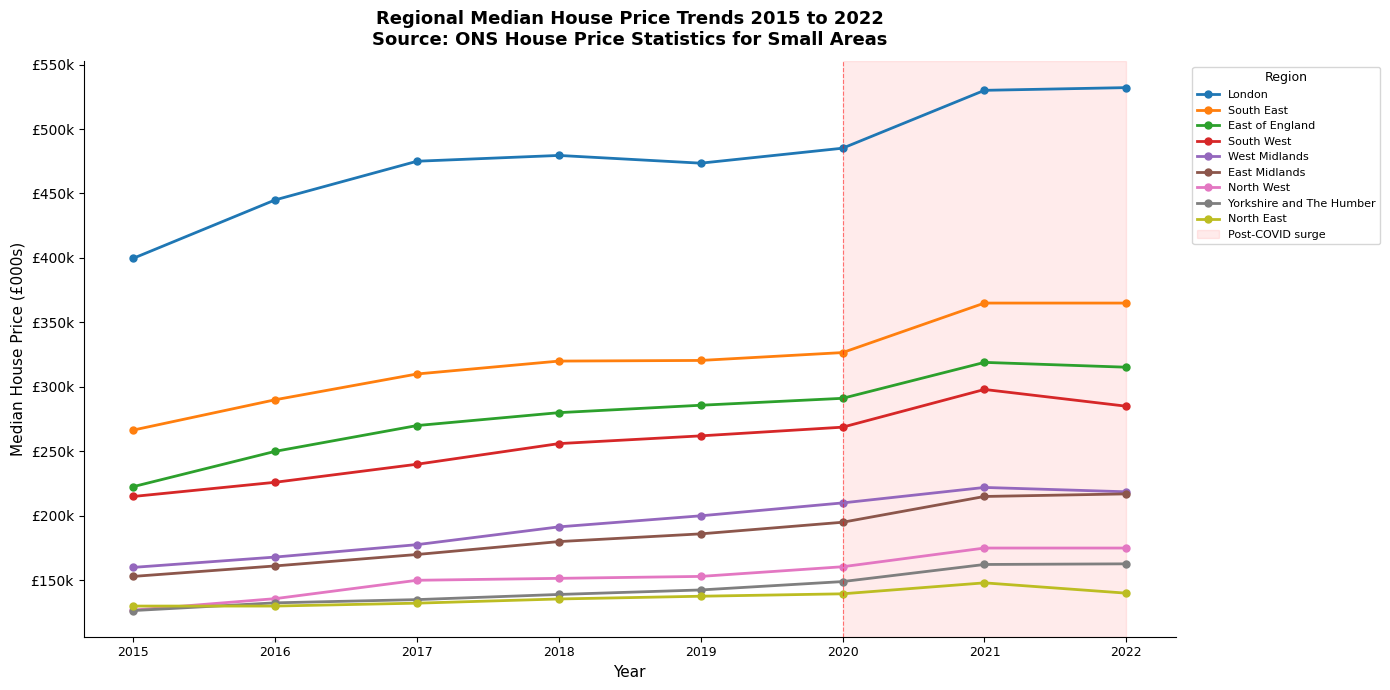

Saved: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project4\figures\04_price_surge_regions.png


In [9]:
# Region order for legend — most to least expensive in 2022
region_order_2022 = (
    region_time[region_time["year"] == 2022]
    .sort_values("median_price", ascending=False)["region_name"]
    .tolist()
)

palette_time = dict(zip(
    region_order_2022,
    sns.color_palette("tab10", len(region_order_2022))
))

fig, ax = plt.subplots(figsize=(14, 7))

for region in region_order_2022:
    data = region_time[region_time["region_name"] == region]
    ax.plot(
        data["year"], data["median_price"] / 1000,
        marker="o", markersize=5, linewidth=2,
        label=region, color=palette_time[region]
    )

# Shade post-COVID period
ax.axvspan(2020, 2022, alpha=0.08, color="red", label="Post-COVID surge")
ax.axvline(x=2020, color="red", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_title(
    "Regional Median House Price Trends 2015 to 2022\n"
    "Source: ONS House Price Statistics for Small Areas",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Median House Price (£000s)", fontsize=11)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda val, pos: f"£{val:,.0f}k"
))

years = sorted(region_time["year"].unique())
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], fontsize=9)

ax.legend(
    title="Region", fontsize=8, title_fontsize=9,
    bbox_to_anchor=(1.01, 1), loc="upper left"
)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(config.FIG_PRICE_SURGE, dpi=config.FIGURE_DPI,
            bbox_inches="tight")
plt.show()
print(f"Saved: {config.FIG_PRICE_SURGE}")

### Explanation of the Figure Above

The post-COVID surge shading makes the 2020 to 2022 acceleration immediately visible. The London line sitting well above all other regions throughout, the convergence of the northern regions at the bottom, and the steeper gradients for all regions inside the shaded zone all tell the story clearly. The legend ordering from most to least expensive in 2022 matches the line ordering on the right side of the chart perfectly.

## Section 6 — Figure 5: Deprivation vs Affordability Scatter

Figure 5 plots IMD score against affordability ratio for all 295 English
local authorities with complete data. Points are coloured by region. A
regression line is overlaid to show the negative relationship confirmed
in notebook 02: more deprived areas tend to have lower affordability
ratios. Individual LAs are labelled where they represent notable outliers
or analytical interest.

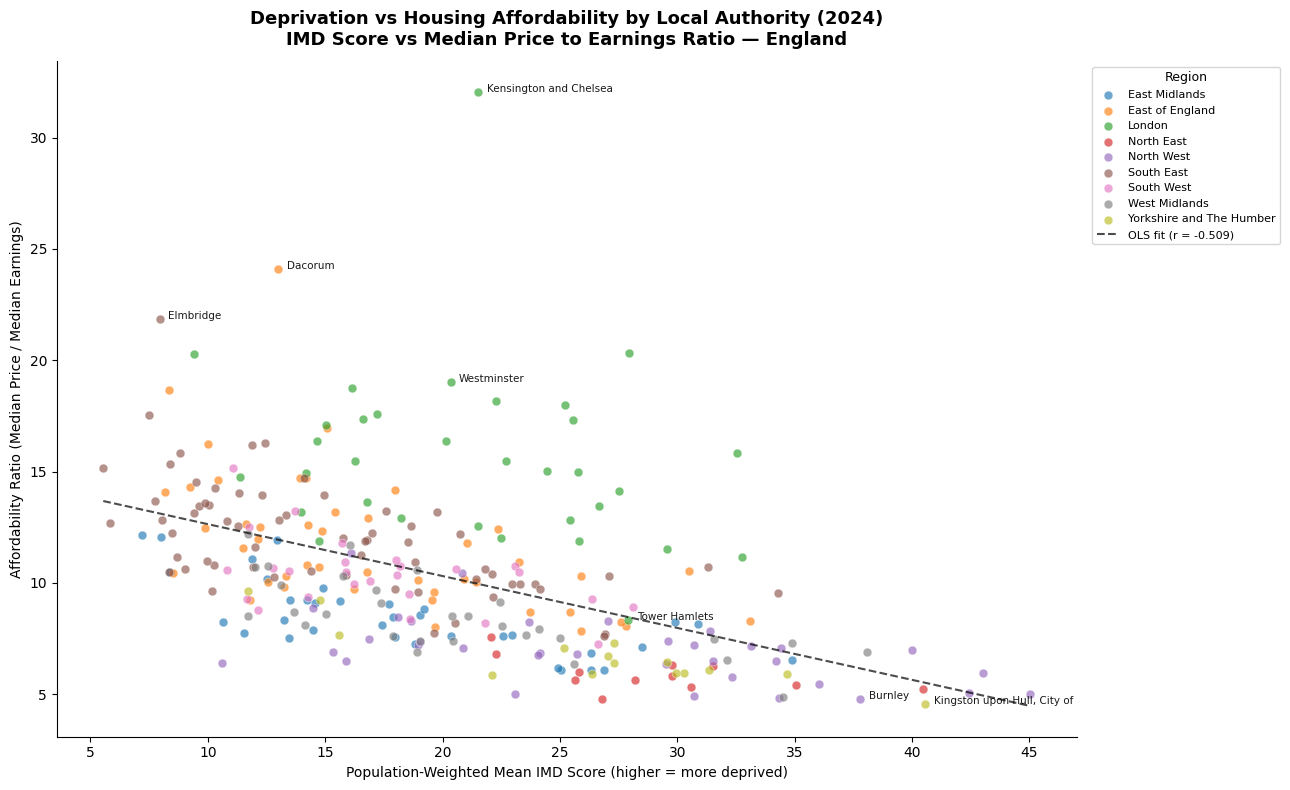

Saved: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project4\figures\05_deprivation_vs_affordability.png


In [15]:
# Prepare data
df_fig5 = df.dropna(subset=["affordability_ratio", "imd_score_wtd"]).copy()

# Notable LAs to label
label_las = [
    "Kensington and Chelsea", "Dacorum", "Kingston upon Hull, City of",
    "Burnley", "Tower Hamlets", "Westminster", "Elmbridge"
]

fig, ax = plt.subplots(figsize=(13, 8))

regions = sorted(df_fig5["region_name"].unique())
palette = dict(zip(regions, sns.color_palette("tab10", len(regions))))

for region in regions:
    subset = df_fig5[df_fig5["region_name"] == region]
    ax.scatter(
        subset["imd_score_wtd"],
        subset["affordability_ratio"],
        color=palette[region],
        label=region,
        alpha=0.65,
        s=40,
        edgecolors="white",
        linewidth=0.4
    )

# Regression line
from numpy.polynomial.polynomial import polyfit
x_vals = df_fig5["imd_score_wtd"].values
y_vals = df_fig5["affordability_ratio"].values
coeffs = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
y_line = np.polyval(coeffs, x_line)
ax.plot(x_line, y_line, color="black", linewidth=1.5,
        linestyle="--", alpha=0.7, label=f"OLS fit (r = -0.509)")

# Label notable LAs
for _, row in df_fig5[df_fig5["lad_name"].isin(label_las)].iterrows():
    ax.annotate(
        row["lad_name"],
        xy=(row["imd_score_wtd"], row["affordability_ratio"]),
        xytext=(6, 0), textcoords="offset points",
        fontsize=7.5, alpha=0.9,
        arrowprops=dict(arrowstyle="-", color="grey",
                        lw=0.5, alpha=0.5)
    )

ax.set_title(
    "Deprivation vs Housing Affordability by Local Authority (2024)\n"
    "IMD Score vs Median Price to Earnings Ratio — England",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Population-Weighted Mean IMD Score (higher = more deprived)",
              fontsize=10)
ax.set_ylabel("Affordability Ratio (Median Price / Median Earnings)",
              fontsize=10)

ax.legend(
    title="Region", fontsize=8, title_fontsize=9,
    bbox_to_anchor=(1.01, 1), loc="upper left"
)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(config.FIG_DEPRIVATION_SCATTER, dpi=config.FIGURE_DPI,
            bbox_inches="tight")
plt.show()
print(f"Saved: {config.FIG_DEPRIVATION_SCATTER}")

### Explanation of the Figure Above

The negative relationship is clearly visible -- the regression line slopes downward from left to right, confirming that more deprived areas have lower affordability ratios. The London green points cluster in the upper-left quadrant -- low deprivation, high unaffordability -- which is the London paradox in visual form. Kensington and Chelsea sits as a clear outlier above the cloud. Burnley and Hull anchor the bottom-right corner. The regional colour coding immediately shows the geographic clustering.

The London paradox is visible -- Tower Hamlets, one of the most deprived London boroughs, sits at an affordability ratio of around 8 despite high deprivation. This is because deprivation in London coexists with high house prices driven by the city-wide premium, producing a pattern that sits above the regression line for its deprivation level.